# 04. Modelos de bagging

Este cuaderno entrena y compara modelos basados en bagging para clasificación y regresión: Bagging con CART, Random Forest y Extra Trees.


#### Índice

1. Librerías utilizadas.
2. Carga y preparación de los datos.
3. Modelos de bagging para clasificación.
4. Modelos de bagging para regresión.
5. Guardado de resultados.


## 1. Librerías utilizadas


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import BaggingClassifier, BaggingRegressor, ExtraTreesClassifier, ExtraTreesRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_absolute_error, mean_squared_error, precision_score, recall_score, r2_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit, ParameterGrid
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

## 2. Carga y preparación de los datos

Las variables categóricas del problema de clasificación se codifican mediante `pd.get_dummies`. En regresión se utilizan exclusivamente las variables temporales y los valores pasados creados durante el preprocesamiento.


In [2]:
bank_train = pd.read_csv("../../data/processed/serie_computacional/bank_train_sin_duration.csv")
bank_test = pd.read_csv("../../data/processed/serie_computacional/bank_test_sin_duration.csv")

power_train = pd.read_csv("../../data/processed/serie_computacional/power_train_hourly.csv",parse_dates=["datetime"])

power_test = pd.read_csv("../../data/processed/serie_computacional/power_test_hourly.csv",parse_dates=["datetime"])

objetivo_clasificacion = "y"
objetivo_regresion = "Global_active_energy_kwh"

assert "duration" not in bank_train.columns
assert "duration" not in bank_test.columns
assert objetivo_clasificacion in bank_train.columns
assert objetivo_clasificacion in bank_test.columns
assert objetivo_regresion in power_train.columns
assert objetivo_regresion in power_test.columns

X_train_bank = bank_train.drop(columns=[objetivo_clasificacion]).copy()
y_train_bank = bank_train[objetivo_clasificacion].copy()

X_test_bank = bank_test.drop(columns=[objetivo_clasificacion]).copy()
y_test_bank = bank_test[objetivo_clasificacion].copy()

variables_numericas_bank = [
    col for col in X_train_bank.columns
    if pd.api.types.is_numeric_dtype(X_train_bank[col])
]

variables_categoricas_bank = [
    col for col in X_train_bank.columns
    if col not in variables_numericas_bank
]

for col in variables_numericas_bank:
    mediana = X_train_bank[col].median()
    X_train_bank[col] = X_train_bank[col].fillna(mediana)
    X_test_bank[col] = X_test_bank[col].fillna(mediana)

for col in variables_categoricas_bank:
    X_train_bank[col] = X_train_bank[col].fillna("missing")
    X_test_bank[col] = X_test_bank[col].fillna("missing")

datos_bank = pd.concat([X_train_bank, X_test_bank], axis=0)
datos_bank = pd.get_dummies(datos_bank, columns=variables_categoricas_bank)

X_train_bank_modelo = datos_bank.iloc[:len(X_train_bank)].copy()
X_test_bank_modelo = datos_bank.iloc[len(X_train_bank):].copy()

X_train_power = power_train.drop(columns=[objetivo_regresion, "datetime"]).copy()
y_train_power = power_train[objetivo_regresion].copy()

X_test_power = power_test.drop(columns=[objetivo_regresion, "datetime"]).copy()
y_test_power = power_test[objetivo_regresion].copy()

variables_numericas_power = list(X_train_power.columns)

for col in variables_numericas_power:
    mediana = X_train_power[col].median()
    X_train_power[col] = X_train_power[col].fillna(mediana)
    X_test_power[col] = X_test_power[col].fillna(mediana)

resumen_preparacion = pd.DataFrame([
    {
        "bloque": "clasificación",
        "train": len(X_train_bank_modelo),
        "test": len(X_test_bank_modelo),
        "variables": X_train_bank_modelo.shape[1],
        "objetivo": objetivo_clasificacion,
    },
    {
        "bloque": "regresión",
        "train": len(X_train_power),
        "test": len(X_test_power),
        "variables": X_train_power.shape[1],
        "objetivo": objetivo_regresion,
    },
])

resumen_preparacion


,bloque,train,test,variables,objetivo
0,clasificación,36168,9043,50,y
1,regresión,27133,6784,14,Global_active_energy_kwh


## 3. Modelos de bagging para clasificación

La búsqueda de hiperparámetros se lleva a cabo mediante validación cruzada estratificada. El F1 de la clase positiva constituye la métrica principal de selección y el ROC-AUC se calcula como métrica complementaria. El conjunto de prueba se utiliza únicamente para la evaluación final.


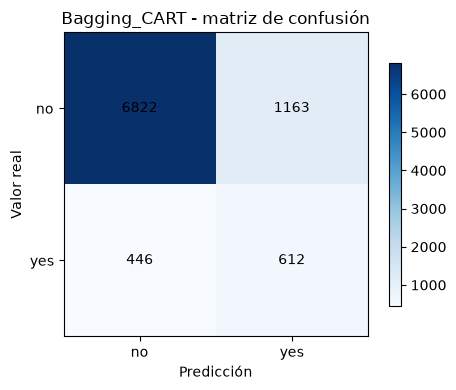

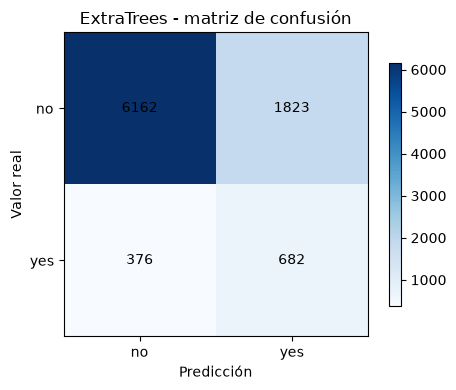

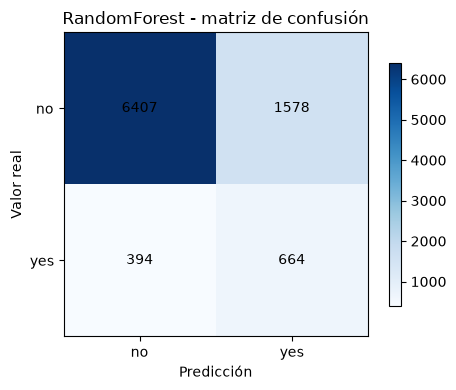

,dataset,escenario,modelo,indice_configuracion,f1_positivo,precision_positiva,recall_positivo,roc_auc,accuracy,n_train,n_test,n_variables_originales,n_variables_numericas,n_variables_categoricas,parametros
0,Bank Marketing,sin_duration,Bagging_CART,5,0.432051,0.344789,0.578450,0.785536,0.822072,36168,9043,15,6,9,"{'max_depth': 8, 'min_samples_leaf': 50, 'n_es..."
1,Bank Marketing,sin_duration,ExtraTrees,21,0.382823,0.272255,0.644612,0.778873,0.756828,36168,9043,15,6,9,"{'max_depth': 8, 'min_samples_leaf': 50, 'n_es..."
2,Bank Marketing,sin_duration,RandomForest,13,0.402424,0.296164,0.627599,0.785564,0.781931,36168,9043,15,6,9,"{'max_depth': 8, 'min_samples_leaf': 50, 'n_es..."


In [3]:
rejilla_comun_clasificacion = {
    "n_estimators": [50, 100],
    "max_depth": [6, 8],
    "min_samples_leaf": [50, 100],
}

configuraciones_clasificacion = []

for nombre_modelo in ["Bagging_CART", "RandomForest", "ExtraTrees"]:
    for parametros in ParameterGrid(rejilla_comun_clasificacion):
        configuracion = {"modelo": nombre_modelo}
        configuracion.update(parametros)
        configuraciones_clasificacion.append(configuracion)

cv_clasificacion = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
filas_busqueda_clasificacion = []

for indice_configuracion, configuracion in enumerate(configuraciones_clasificacion):
    valores_f1 = []
    valores_roc = []

    for indices_train, indices_validacion in cv_clasificacion.split(X_train_bank_modelo, y_train_bank):
        if configuracion["modelo"] == "Bagging_CART":
            modelo = BaggingClassifier(
                estimator=DecisionTreeClassifier(max_depth=configuracion["max_depth"], min_samples_leaf=configuracion["min_samples_leaf"], class_weight="balanced", random_state=42),
                n_estimators=configuracion["n_estimators"],
                random_state=42,
                n_jobs=1,
            )
        elif configuracion["modelo"] == "RandomForest":
            modelo = RandomForestClassifier(
                n_estimators=configuracion["n_estimators"],
                max_depth=configuracion["max_depth"],
                min_samples_leaf=configuracion["min_samples_leaf"],
                class_weight="balanced",
                random_state=42,
                n_jobs=1,
            )
        else:
            modelo = ExtraTreesClassifier(
                n_estimators=configuracion["n_estimators"],
                max_depth=configuracion["max_depth"],
                min_samples_leaf=configuracion["min_samples_leaf"],
                class_weight="balanced",
                random_state=42,
                n_jobs=1,
            )

        modelo.fit(X_train_bank_modelo.iloc[indices_train], y_train_bank.iloc[indices_train])
        predicciones_validacion = modelo.predict(X_train_bank_modelo.iloc[indices_validacion])
        probabilidades_validacion = modelo.predict_proba(X_train_bank_modelo.iloc[indices_validacion])[:, 1]

        valores_f1.append(f1_score(y_train_bank.iloc[indices_validacion], predicciones_validacion, pos_label=1, zero_division=0))
        valores_roc.append(roc_auc_score(y_train_bank.iloc[indices_validacion], probabilidades_validacion))

    filas_busqueda_clasificacion.append({
        "indice_configuracion": indice_configuracion,
        "modelo": configuracion["modelo"],
        "parametros": str({k: v for k, v in configuracion.items() if k != "modelo"}),
        "f1_positivo_cv_media": np.mean(valores_f1),
        "f1_positivo_cv_std": np.std(valores_f1),
        "roc_auc_cv_media": np.mean(valores_roc),
        "roc_auc_cv_std": np.std(valores_roc),
    })

busqueda_bagging_clasificacion = pd.DataFrame(filas_busqueda_clasificacion)

mejores_bagging_clasificacion = (
    busqueda_bagging_clasificacion
    .sort_values(["modelo", "f1_positivo_cv_media", "roc_auc_cv_media"], ascending=[True, False, False])
    .groupby("modelo", as_index=False)
    .head(1)
)

filas_clasificacion = []
filas_matrices = []
matrices_para_grafico = {}

for _, fila_mejor in mejores_bagging_clasificacion.iterrows():
    configuracion = configuraciones_clasificacion[int(fila_mejor["indice_configuracion"])]

    if configuracion["modelo"] == "Bagging_CART":
        modelo = BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=configuracion["max_depth"], min_samples_leaf=configuracion["min_samples_leaf"], class_weight="balanced", random_state=42),
            n_estimators=configuracion["n_estimators"],
            random_state=42,
            n_jobs=1,
        )
    elif configuracion["modelo"] == "RandomForest":
        modelo = RandomForestClassifier(
            n_estimators=configuracion["n_estimators"],
            max_depth=configuracion["max_depth"],
            min_samples_leaf=configuracion["min_samples_leaf"],
            class_weight="balanced",
            random_state=42,
            n_jobs=1,
        )
    else:
        modelo = ExtraTreesClassifier(
            n_estimators=configuracion["n_estimators"],
            max_depth=configuracion["max_depth"],
            min_samples_leaf=configuracion["min_samples_leaf"],
            class_weight="balanced",
            random_state=42,
            n_jobs=1,
        )

    modelo.fit(X_train_bank_modelo, y_train_bank)
    predicciones = modelo.predict(X_test_bank_modelo)
    probabilidades = modelo.predict_proba(X_test_bank_modelo)[:, 1]

    matriz = confusion_matrix(y_test_bank, predicciones, labels=[0, 1])
    tn, fp, fn, tp = matriz.ravel()
    matrices_para_grafico[configuracion["modelo"]] = matriz

    filas_clasificacion.append({
        "dataset": "Bank Marketing",
        "escenario": "sin_duration",
        "modelo": configuracion["modelo"],
        "indice_configuracion": int(fila_mejor["indice_configuracion"]),
        "f1_positivo": f1_score(y_test_bank, predicciones, pos_label=1, zero_division=0),
        "precision_positiva": precision_score(y_test_bank, predicciones, pos_label=1, zero_division=0),
        "recall_positivo": recall_score(y_test_bank, predicciones, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_test_bank, probabilidades),
        "accuracy": accuracy_score(y_test_bank, predicciones),
        "n_train": len(X_train_bank_modelo),
        "n_test": len(X_test_bank_modelo),
        "n_variables_originales": X_train_bank.shape[1],
        "n_variables_numericas": len(variables_numericas_bank),
        "n_variables_categoricas": len(variables_categoricas_bank),
        "parametros": str({k: v for k, v in configuracion.items() if k != "modelo"}),
    })

    filas_matrices.append({
        "dataset": "Bank Marketing",
        "escenario": "sin_duration",
        "modelo": configuracion["modelo"],
        "indice_configuracion": int(fila_mejor["indice_configuracion"]),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    })

resultados_bagging_clasificacion = pd.DataFrame(filas_clasificacion)
matrices_bagging_clasificacion = pd.DataFrame(filas_matrices)

for nombre_modelo, matriz in matrices_para_grafico.items():
    fig, ax = plt.subplots(figsize=(5, 4))
    imagen = ax.imshow(matriz, cmap="Blues")
    ax.set_title(f"{nombre_modelo} - matriz de confusión")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticks([0, 1], labels=["no", "yes"])
    ax.set_yticks([0, 1], labels=["no", "yes"])

    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            ax.text(j, i, matriz[i, j], ha="center", va="center", color="black")

    fig.colorbar(imagen, ax=ax, shrink=0.8)
    fig.tight_layout()
    plt.show()

resultados_bagging_clasificacion

## 4. Modelos de bagging para regresión

Los modelos de regresión se ajustan mediante validación temporal, preservando el orden cronológico de los datos. El RMSE es la métrica principal de selección y el R² se emplea como medida complementaria.


In [4]:
rejilla_comun_regresion = {
    "n_estimators": [50, 100],
    "max_depth": [6, 8],
    "min_samples_leaf": [50, 100],
}

configuraciones_regresion = []

for nombre_modelo in ["Bagging_CART", "RandomForest", "ExtraTrees"]:
    for parametros in ParameterGrid(rejilla_comun_regresion):
        configuracion = {"modelo": nombre_modelo}
        configuracion.update(parametros)
        configuraciones_regresion.append(configuracion)

cv_temporal = TimeSeriesSplit(n_splits=3)
filas_busqueda_regresion = []

for indice_configuracion, configuracion in enumerate(configuraciones_regresion):
    valores_rmse = []
    valores_r2 = []

    for indices_train, indices_validacion in cv_temporal.split(X_train_power):
        if configuracion["modelo"] == "Bagging_CART":
            modelo = BaggingRegressor(
                estimator=DecisionTreeRegressor(
                    max_depth=configuracion["max_depth"],
                    min_samples_leaf=configuracion["min_samples_leaf"],
                    random_state=42,
                ),
                n_estimators=configuracion["n_estimators"],
                random_state=42,
                n_jobs=1,
            )
        elif configuracion["modelo"] == "RandomForest":
            modelo = RandomForestRegressor(
                n_estimators=configuracion["n_estimators"],
                max_depth=configuracion["max_depth"],
                min_samples_leaf=configuracion["min_samples_leaf"],
                random_state=42,
                n_jobs=1,
            )
        else:
            modelo = ExtraTreesRegressor(
                n_estimators=configuracion["n_estimators"],
                max_depth=configuracion["max_depth"],
                min_samples_leaf=configuracion["min_samples_leaf"],
                random_state=42,
                n_jobs=1,
            )

        modelo.fit(X_train_power.iloc[indices_train], y_train_power.iloc[indices_train])
        predicciones_validacion = modelo.predict(X_train_power.iloc[indices_validacion])

        mse_validacion = mean_squared_error(
            y_train_power.iloc[indices_validacion],
            predicciones_validacion,
        )

        valores_rmse.append(np.sqrt(mse_validacion))
        valores_r2.append(
            r2_score(
                y_train_power.iloc[indices_validacion],
                predicciones_validacion,
            )
        )

    filas_busqueda_regresion.append({
        "indice_configuracion": indice_configuracion,
        "modelo": configuracion["modelo"],
        "parametros": str({k: v for k, v in configuracion.items() if k != "modelo"}),
        "rmse_cv_media": np.mean(valores_rmse),
        "rmse_cv_std": np.std(valores_rmse),
        "r2_cv_media": np.mean(valores_r2),
        "r2_cv_std": np.std(valores_r2),
    })

busqueda_bagging_regresion = pd.DataFrame(filas_busqueda_regresion)

mejores_bagging_regresion = (
    busqueda_bagging_regresion
    .sort_values(["modelo", "rmse_cv_media", "r2_cv_media"], ascending=[True, True, False])
    .groupby("modelo", as_index=False)
    .head(1)
)

filas_regresion = []

for _, fila_mejor in mejores_bagging_regresion.iterrows():
    configuracion = configuraciones_regresion[int(fila_mejor["indice_configuracion"])]

    if configuracion["modelo"] == "Bagging_CART":
        modelo = BaggingRegressor(
            estimator=DecisionTreeRegressor(
                max_depth=configuracion["max_depth"],
                min_samples_leaf=configuracion["min_samples_leaf"],
                random_state=42,
            ),
            n_estimators=configuracion["n_estimators"],
            random_state=42,
            n_jobs=1,
        )
    elif configuracion["modelo"] == "RandomForest":
        modelo = RandomForestRegressor(
            n_estimators=configuracion["n_estimators"],
            max_depth=configuracion["max_depth"],
            min_samples_leaf=configuracion["min_samples_leaf"],
            random_state=42,
            n_jobs=1,
        )
    else:
        modelo = ExtraTreesRegressor(
            n_estimators=configuracion["n_estimators"],
            max_depth=configuracion["max_depth"],
            min_samples_leaf=configuracion["min_samples_leaf"],
            random_state=42,
            n_jobs=1,
        )

    modelo.fit(X_train_power, y_train_power)
    predicciones = modelo.predict(X_test_power)
    mse = mean_squared_error(y_test_power, predicciones)

    filas_regresion.append({
        "dataset": "Individual Household Electric Power Consumption",
        "modelo": configuracion["modelo"],
        "indice_configuracion": int(fila_mejor["indice_configuracion"]),
        "rmse": np.sqrt(mse),
        "mae": mean_absolute_error(y_test_power, predicciones),
        "mse": mse,
        "r2": r2_score(y_test_power, predicciones),
        "n_train": len(X_train_power),
        "n_test": len(X_test_power),
        "n_variables_originales": X_train_power.shape[1],
        "n_variables_numericas": len(variables_numericas_power),
        "n_variables_categoricas": 0,
        "parametros": str({k: v for k, v in configuracion.items() if k != "modelo"}),
    })

resultados_bagging_regresion = pd.DataFrame(filas_regresion)

resultados_bagging_regresion

,dataset,modelo,indice_configuracion,rmse,mae,mse,r2,n_train,n_test,n_variables_originales,n_variables_numericas,n_variables_categoricas,parametros
0,Individual Household Electric Power Consumption,Bagging_CART,5,0.483460,0.335209,0.233733,0.576896,27133,6784,14,14,0,"{'max_depth': 8, 'min_samples_leaf': 50, 'n_es..."
1,Individual Household Electric Power Consumption,ExtraTrees,21,0.495383,0.351414,0.245404,0.555770,27133,6784,14,14,0,"{'max_depth': 8, 'min_samples_leaf': 50, 'n_es..."
2,Individual Household Electric Power Consumption,RandomForest,13,0.483460,0.335209,0.233733,0.576896,27133,6784,14,14,0,"{'max_depth': 8, 'min_samples_leaf': 50, 'n_es..."


## 5. Guardado de resultados

En este bloque se guardan las métricas de evaluación, los resultados de validación y las matrices de confusión de los modelos de bagging.


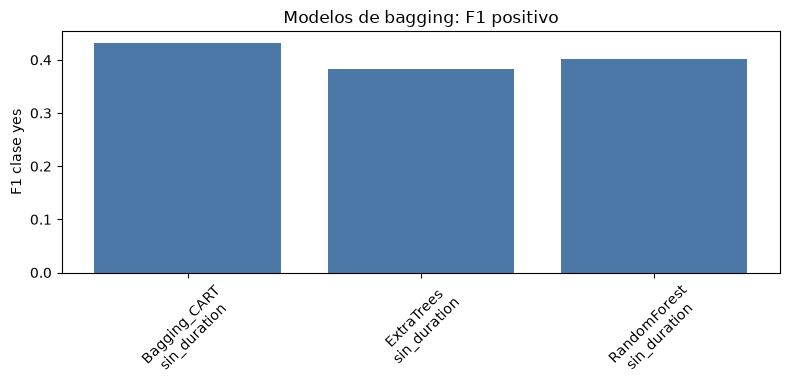

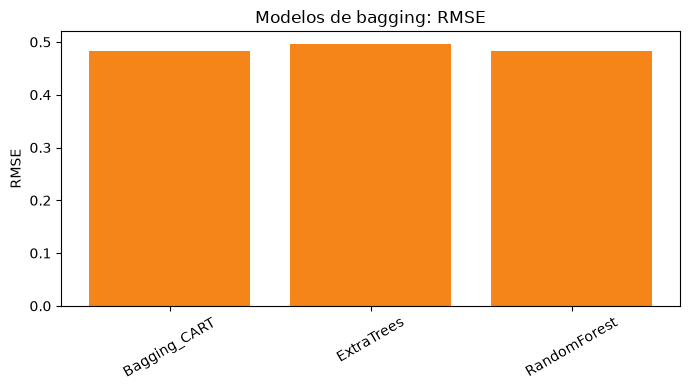

In [5]:
ruta_tablas = "../../reports/tables/serie_computacional"
ruta_figuras = "../../reports/figures/serie_computacional"

os.makedirs(ruta_tablas, exist_ok=True)
os.makedirs(ruta_figuras, exist_ok=True)

resultados_bagging_clasificacion.to_csv(f"{ruta_tablas}/bagging_clasificacion_metricas.csv", index=False)
resultados_bagging_regresion.to_csv(f"{ruta_tablas}/bagging_regresion_metricas.csv", index=False)

busqueda_bagging_clasificacion.to_csv(f"{ruta_tablas}/bagging_busqueda_hiperparametros_clasificacion.csv", index=False)
busqueda_bagging_regresion.to_csv(f"{ruta_tablas}/bagging_busqueda_hiperparametros_regresion.csv", index=False)

busqueda_bagging_clasificacion.to_csv(f"{ruta_tablas}/bagging_validacion_cruzada_clasificacion.csv", index=False)
busqueda_bagging_regresion.to_csv(f"{ruta_tablas}/bagging_validacion_temporal_regresion.csv", index=False)

matrices_bagging_clasificacion.to_csv(f"{ruta_tablas}/bagging_matrices_confusion.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))

grafico = resultados_bagging_clasificacion.copy()
grafico["etiqueta"] = grafico["modelo"] + "\n" + grafico["escenario"]

ax.bar(grafico["etiqueta"], grafico["f1_positivo"], color="#4c78a8")
ax.set_title("Modelos de bagging: F1 positivo")
ax.set_ylabel("F1 clase yes")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(f"{ruta_figuras}/bagging_clasificacion_f1.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(resultados_bagging_regresion["modelo"], resultados_bagging_regresion["rmse"], color="#f58518")
ax.set_title("Modelos de bagging: RMSE")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=30)

fig.tight_layout()
fig.savefig(f"{ruta_figuras}/bagging_regresion_rmse.png", dpi=150, bbox_inches="tight")
plt.show()
